##### ***ResNet***
###### 随着我们设计越来越深的网络，我们要怎么确保加深的网络会让性能得到提高而不是退化呢？假定我们有一类神经网络框架，然而它的不同层数的网络如果不是嵌套类的，那么可能会出现性能退化的问题。因此，只有当较复杂的函数类包含较小的函数类时，我们才能确保提高它们的性能，如下图：
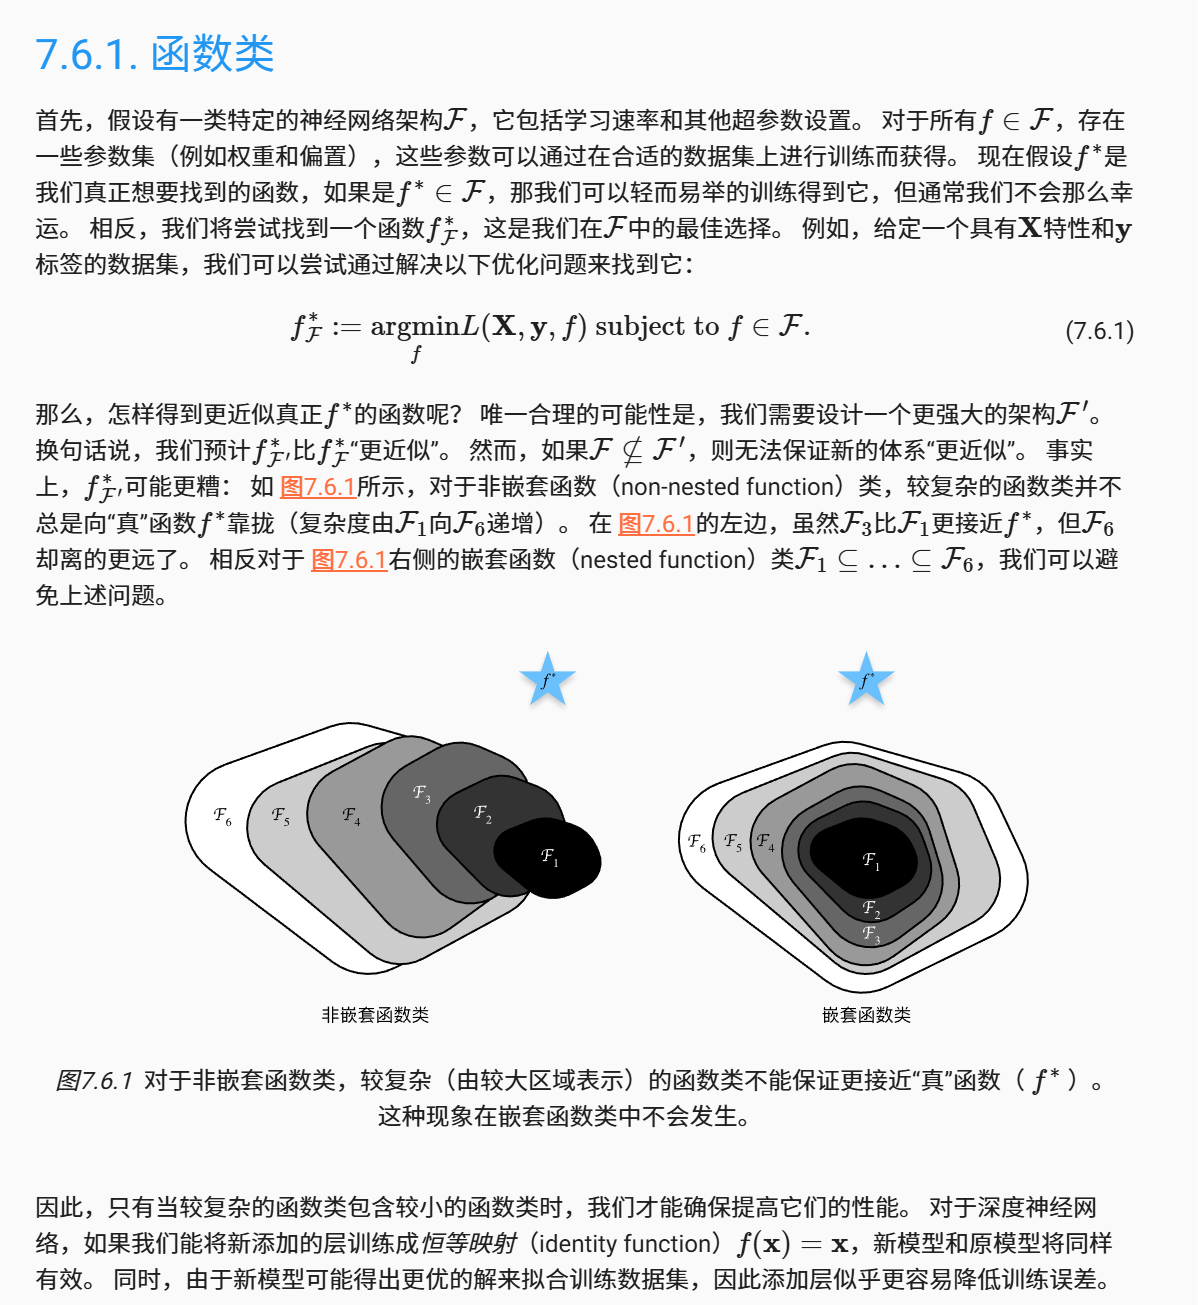
###### 因此提出了残差网络ResNet，它的基本思想是引入残差块（Residual Block），每个附加层都应该能容易地包含原始函数作为其元素之一。
###### 假如我们的输入是X，我们想要得到的映射是f(X)，往常的做法是直接将其映射到f(X)，而残差网络的做法是将其映射到f(X)-X，而后再加上输入。残差映射在现实中往往容易优化。
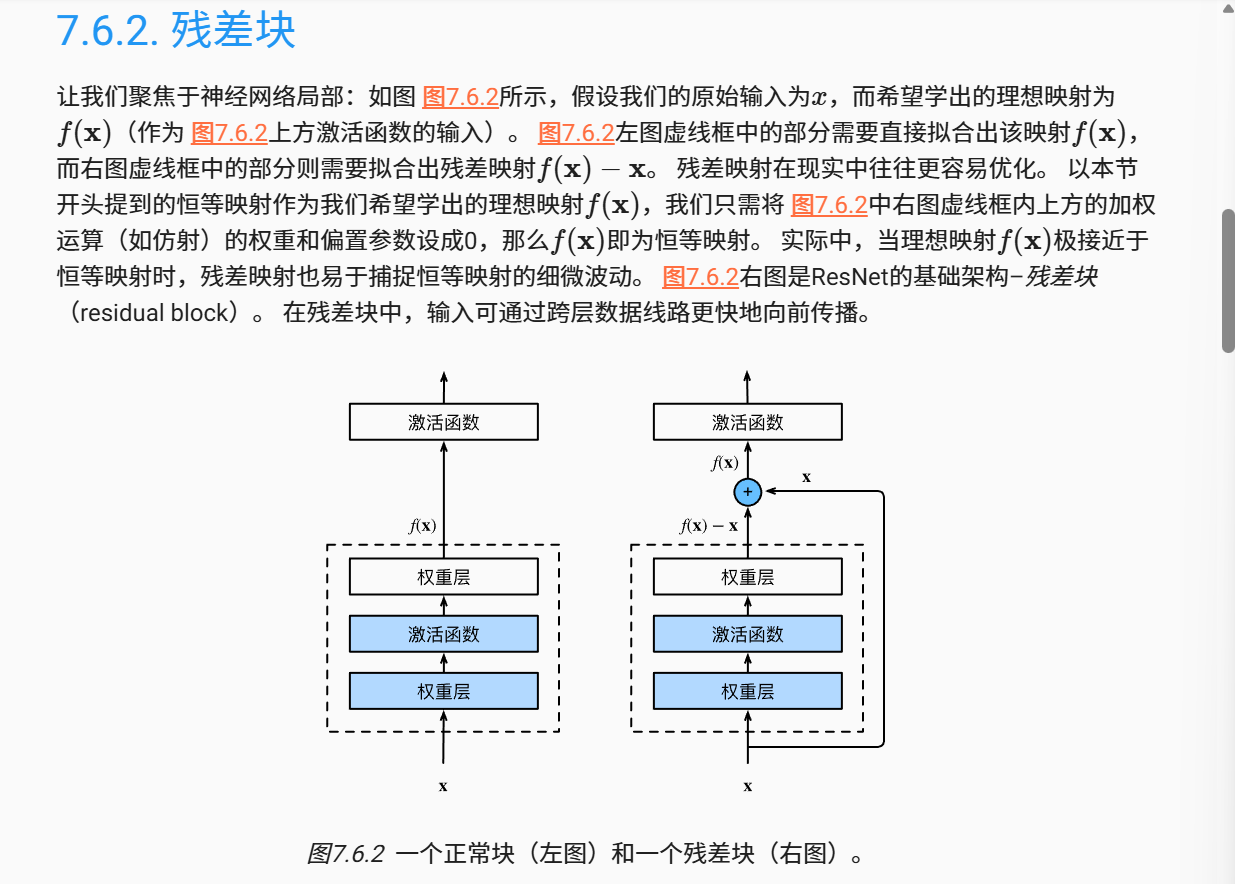
###### 在没有残差的时候普通网络的每一层都在尝试y=f(X)，随着深度的加深，由于链式法则的存在，梯度可能会爆炸或者消失，而且添加的那些层可能不一定会学到有用的信息，它们反而可能破坏已有的表示，多出来的层只是负担。而残差网络不直接学f(X)，而是学F(X)=f(X)-X，最终输出X+F(X)，也就是说其实残差网络考虑了如果出现恒等映射这个特殊情况，而普通网络会必须要求学点什么，但是这个映射要求的就是恒等，所以残差网络允许F(X)为0，也就是说直接不做新变换就好，所以普通网络这时候可能会越学越差，而残差网络不会，残差结构并不显式判断某一层是否有用，而是通过将恒等映射作为一个易于实现的特例，使得在优化过程中，无效或有害的层可以自然退化为恒等映射，从而避免性能退化。

In [14]:
import torch
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l

class Residual(nn.Module): #@save
    def __init__(self, input_channels, num_channels, use_1x1conv=False, strides=1):
        super().__init__()
        self.conv1 = nn.Conv2d(input_channels, num_channels, kernel_size=3, padding=1, stride=strides)
        self.conv2 = nn.Conv2d(num_channels, num_channels, kernel_size=3, padding=1)
        if use_1x1conv:
            self.conv3 = nn.Conv2d(input_channels, num_channels, kernel_size=1, stride=strides)
        else:
            self.conv3 = None
        self.bn1 = nn.BatchNorm2d(num_channels)
        self.bn2 = nn.BatchNorm2d(num_channels)

    def forward(self, X):
        Y = F.relu(self.bn1(self.conv1(X)))
        Y = self.bn2(self.conv2(Y))
        if self.conv3:
            X = self.conv3(X)
        Y += X
        return F.relu(Y)

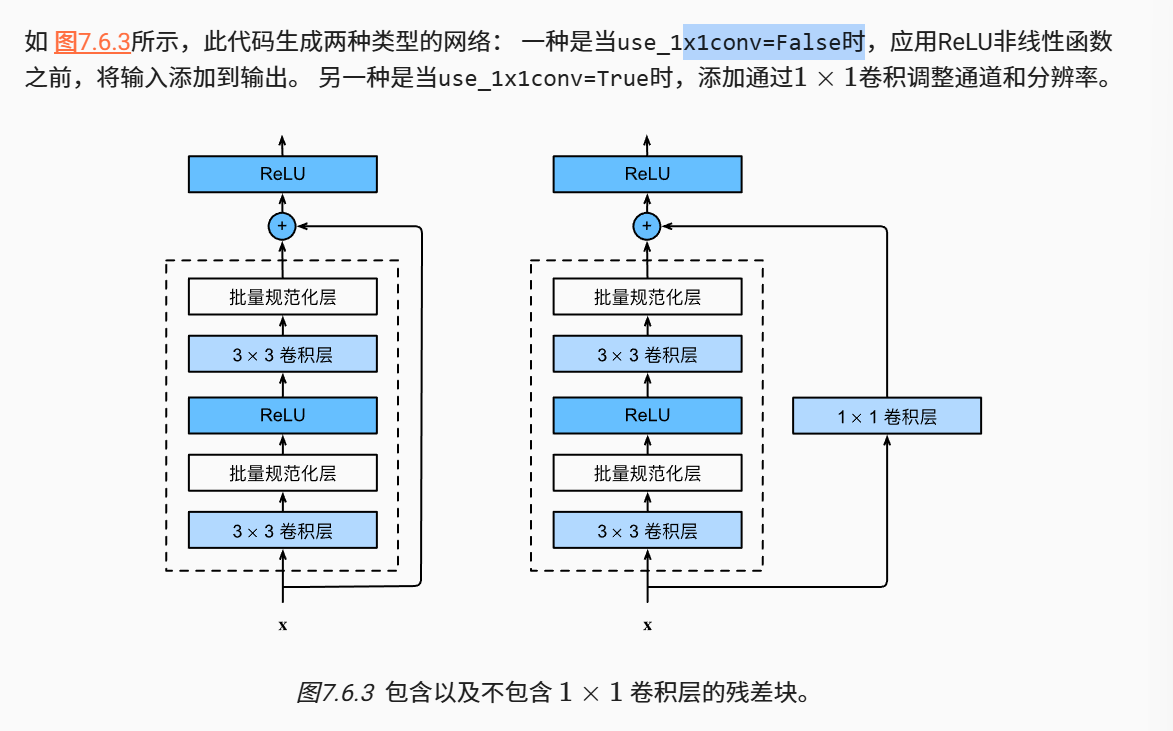

In [15]:
blk = Residual(3,3)
X = torch.rand(4, 3, 6, 6)
Y = blk(X)
Y.shape

torch.Size([4, 3, 6, 6])

In [16]:
blk = Residual(3, 6, use_1x1conv=True, strides=2)
blk(X).shape

torch.Size([4, 6, 3, 3])

##### ***ResNet模型***
###### 和GoogLeNet类似，ResNet在输出通道数为64、步幅为2的7x7卷积层后，接步幅为2的3x3最大池化层。不同之处在于ResNet每个卷积层后接了批量规范化层。
###### GoogLeNet在后面接了4个由Inception块组成的模块。 ResNet则使用4个由残差块组成的模块，每个模块使用若干个同样输出通道数的残差块。 第一个模块的通道数同输入通道数一致。 由于之前已经使用了步幅为2的最大汇聚层，所以无须减小高和宽。 之后的每个模块在第一个残差块里将上一个模块的通道数翻倍，并将高和宽减半。
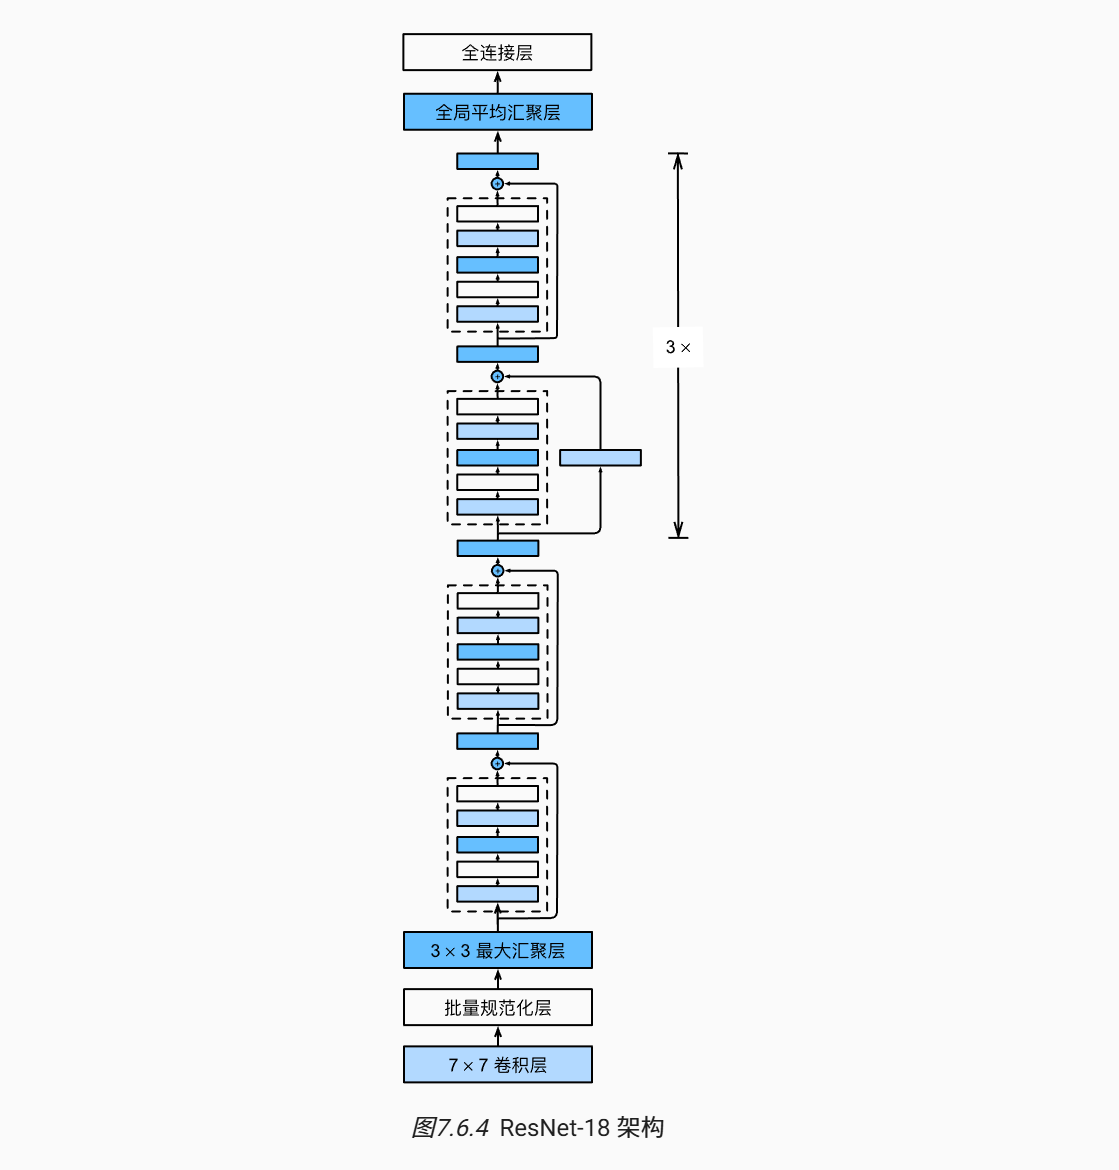

In [17]:
b1 = nn.Sequential(
    nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
)

In [ ]:
def resnet_block(input_channels, num_channels, num_residuals, first_block=False):
    blk = []
    for i in range(num_residuals):
        if i == 0 and not first_block:
            blk.append(Residual(input_channels, num_channels, use_1x1conv=True, strides=2))
        else:
            blk.append(Residual(num_channels, num_channels))
    return blk

In [ ]:
b2 = nn.Sequential(*resnet_block(64, 64, 2, first_block=True))
b3 = nn.Sequential(*resnet_block(64, 128, 2))
b4 = nn.Sequential(*resnet_block(128, 256, 2))
b5 = nn.Sequential(*resnet_block(256, 512, 2))

In [ ]:
net = nn.Sequential(b1, b2, b3, b4, b5,
                    nn.AdaptiveAvgPool2d((1,1)),
                    nn.Flatten(), nn.Linear(512, 10))

In [ ]:
X = torch.rand(size=(1, 1, 224, 224))
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__,'output shape:\t', X.shape)

Sequential output shape:	 torch.Size([1, 64, 56, 56])
Sequential output shape:	 torch.Size([1, 64, 56, 56])
Sequential output shape:	 torch.Size([1, 128, 28, 28])
Sequential output shape:	 torch.Size([1, 256, 14, 14])
Sequential output shape:	 torch.Size([1, 512, 7, 7])
AdaptiveAvgPool2d output shape:	 torch.Size([1, 512, 1, 1])
Flatten output shape:	 torch.Size([1, 512])
Linear output shape:	 torch.Size([1, 10])


KeyboardInterrupt: 

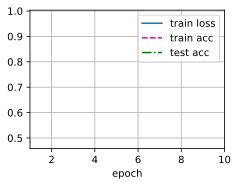

In [22]:
lr, num_epochs, batch_size = 0.05, 10, 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, resize=96)
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())

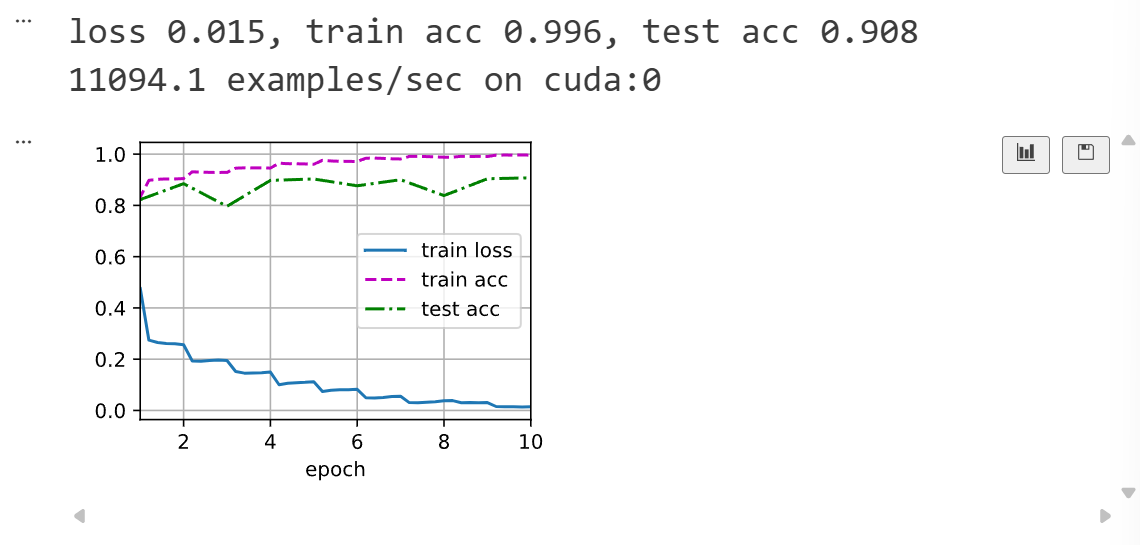